# Första dataanalys – Appliances Energy Prediction

## Syfte

I denna notebook undersöker vi datasetets struktur och datakvalitet
innan vi använder det för modellträning.

Vi kontrollerar bland annat datasetets storlek, kolumner, datatyper,
saknade värden, identiska rader och tidsintervall.

## Vad undersöker vi?

Projektets mål är att undersöka om information om huset och dess
miljö kan användas för att uppskatta hushållsapparaternas energianvändning.

Vår target är `Appliances`. En observation är en hel rad med
mätvärden som hör till en tidsstämpel i kolumnen `date`.

Denna notebook innehåller en första datagranskning.
Modellträning och modelljämförelse görs i senare steg.

## Datakälla

Källa: UCI Machine Learning Repository – Appliances Energy Prediction.

Centrala enheter:
- `Appliances`: Wh
- Temperatur: °C
- Luftfuktighet: %

Fullständig källinformation finns i `data/README.md`.

## Del A - Läs in CSV-filen

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("../data/energydata_complete.csv")

## Del B - Kontrollera att filen lästes in

In [2]:
df.head()

,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,...,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
1,2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,...,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2,2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,...,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
3,2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,...,17.000000,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389
4,2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,...,17.000000,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097


## Del C - Kontroll av datasetets storlek

In [3]:
df.shape

(19735, 29)

##### Resultat: Datasetet innehåller 19735 observationer och 29 kolumner

## Del D - Vilka kolumner finns?

In [4]:
df.columns

Index(['date', 'Appliances', 'lights', 'T1', 'RH_1', 'T2', 'RH_2', 'T3',
       'RH_3', 'T4', 'RH_4', 'T5', 'RH_5', 'T6', 'RH_6', 'T7', 'RH_7', 'T8',
       'RH_8', 'T9', 'RH_9', 'T_out', 'Press_mm_hg', 'RH_out', 'Windspeed',
       'Visibility', 'Tdewpoint', 'rv1', 'rv2'],
      dtype='str')

## Del E - Datatyper

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 19735 entries, 0 to 19734
Data columns (total 29 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         19735 non-null  str    
 1   Appliances   19735 non-null  int64  
 2   lights       19735 non-null  int64  
 3   T1           19735 non-null  float64
 4   RH_1         19735 non-null  float64
 5   T2           19735 non-null  float64
 6   RH_2         19735 non-null  float64
 7   T3           19735 non-null  float64
 8   RH_3         19735 non-null  float64
 9   T4           19735 non-null  float64
 10  RH_4         19735 non-null  float64
 11  T5           19735 non-null  float64
 12  RH_5         19735 non-null  float64
 13  T6           19735 non-null  float64
 14  RH_6         19735 non-null  float64
 15  T7           19735 non-null  float64
 16  RH_7         19735 non-null  float64
 17  T8           19735 non-null  float64
 18  RH_8         19735 non-null  float64
 19  T9           19

## Del F - Kontroll av saknade värden

Vi undersöker om någon kolumn innehåller saknade värden.
Det hjälper oss att avgöra om vi behöver planera någon hantering
av bortfall innan modelleringen.

In [6]:
df.isnull().sum()

date           0
Appliances     0
lights         0
T1             0
RH_1           0
T2             0
RH_2           0
T3             0
RH_3           0
T4             0
RH_4           0
T5             0
RH_5           0
T6             0
RH_6           0
T7             0
RH_7           0
T8             0
RH_8           0
T9             0
RH_9           0
T_out          0
Press_mm_hg    0
RH_out         0
Windspeed      0
Visibility     0
Tdewpoint      0
rv1            0
rv2            0
dtype: int64

**Resultat:** Kontrollen visar inga värden som pandas identifierar
som saknade i någon av kolumnerna.

**Tolkning:** Utifrån denna kontroll finns inget identifierat bortfall
att hantera. Det betyder däremot inte att alla mätvärden automatiskt
är rimliga eller korrekta.

## Del G - Dubletter 

In [7]:
df.duplicated().sum()

np.int64(0)

**Resultat:** Datasetet innehåller inga identiska rader.

## Del H - Grundläggande statistik

In [8]:
df.describe()

,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
count,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,...,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000
mean,97.694958,3.801875,21.686571,40.259739,20.341219,40.420420,22.267611,39.242500,20.855335,39.026904,...,19.485828,41.552401,7.411665,755.522602,79.750418,4.039752,38.330834,3.760707,24.988033,24.988033
std,102.524891,7.935988,1.606066,3.979299,2.192974,4.069813,2.006111,3.254576,2.042884,4.341321,...,2.014712,4.151497,5.317409,7.399441,14.901088,2.451221,11.794719,4.194648,14.496634,14.496634
min,10.000000,0.000000,16.790000,27.023333,16.100000,20.463333,17.200000,28.766667,15.100000,27.660000,...,14.890000,29.166667,-5.000000,729.300000,24.000000,0.000000,1.000000,-6.600000,0.005322,0.005322
25%,50.000000,0.000000,20.760000,37.333333,18.790000,37.900000,20.790000,36.900000,19.530000,35.530000,...,18.000000,38.500000,3.666667,750.933333,70.333333,2.000000,29.000000,0.900000,12.497889,12.497889
50%,60.000000,0.000000,21.600000,39.656667,20.000000,40.500000,22.100000,38.530000,20.666667,38.400000,...,19.390000,40.900000,6.916667,756.100000,83.666667,3.666667,40.000000,3.433333,24.897653,24.897653
75%,100.000000,0.000000,22.600000,43.066667,21.500000,43.260000,23.290000,41.760000,22.100000,42.156667,...,20.600000,44.338095,10.408333,760.933333,91.666667,5.500000,40.000000,6.566667,37.583769,37.583769
max,1080.000000,70.000000,26.260000,63.360000,29.856667,56.026667,29.236000,50.163333,26.200000,51.090000,...,24.500000,53.326667,26.100000,772.300000,100.000000,14.000000,66.000000,15.500000,49.996530,49.996530


**Tolkning:** Medelvärdet är högre än medianen, och maxvärdet
ligger långt över båda. Detta tyder på att höga värden drar upp
medelvärdet.

Vi behandlar inte höga värden som fel enbart för att de är ovanliga.
Deras betydelse behöver undersökas innan eventuell datarensning.

## Del I - Tidskolumnen

In [9]:
df["date"].head()

0    2016-01-11 17:00:00
1    2016-01-11 17:10:00
2    2016-01-11 17:20:00
3    2016-01-11 17:30:00
4    2016-01-11 17:40:00
Name: date, dtype: str

In [10]:
df["date"] = pd.to_datetime(df["date"])

In [11]:
print("Första mättidpunkt:", df["date"].min())
print("Sista mättidpunkt:", df["date"].max())

Första mättidpunkt: 2016-01-11 17:00:00
Sista mättidpunkt: 2016-05-27 18:00:00


In [12]:
df["date"].is_monotonic_increasing

True

## Del J - Kontrollera tidsintervallen

In [13]:
df["date"].diff().value_counts().head()

date
0 days 00:10:00    19734
Name: count, dtype: int64

**Resultat:** Mätningarna ligger med 10 minuters mellanrum genom hela datasetet.

**Tolkning:** 
10-minutersintervallen visar att tidsserien är regelbunden, och det gör det enklare och mer korrekt att dela upp datan tidsmässigt senare. För vi vill träna modellen på äldre mätningar och sedan utvärdera på nyare mätningar.

## Del K - Identifiera target 

Target är Appliances, eftersom det är energianväning från hushållsapparaterna som modellen ska försöka uppskatta

## Del L - Vad representerar observationen

En observation motsvarar ett mättillfälle och innehåller bland annat temperaturer, luftfuktighet, utomhusdata och energianvändning för de tidsintervallet

## Del M - Fördelning av energianvändningen

In [14]:
df["Appliances"].describe()

count    19735.000000
mean        97.694958
std        102.524891
min         10.000000
25%         50.000000
50%         60.000000
75%        100.000000
max       1080.000000
Name: Appliances, dtype: float64

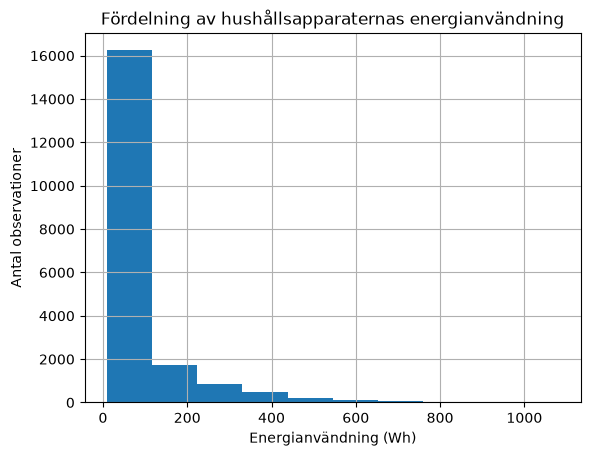

In [15]:

df["Appliances"].hist()
plt.title("Fördelning av hushållsapparaternas energianvändning")
plt.xlabel("Energianvändning (Wh)")
plt.ylabel("Antal observationer")

plt.show()